### CÉLULA 1 — **Instalação**

In [ ]:
!pip install torch torchvision scikit-learn matplotlib seaborn kaggle

### **CÉLULA 2 — Imports**

In [ ]:
import os
import zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Function
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

### **CÉLULA 3 - Upload Kaggle API**

### **CÉLULA 4 - Configurar Kaggle**

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


### **CÉLULA 5 - Download dos Datasets**

In [ ]:
# Source (Pneumonia)
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d data/source
!mkdir -p data/source

# Target (exemplo alternativo — adapte se quiser outro)
import os
import zipfile
import random
import shutil

# =========================
# CONFIG
# =========================
DATASET_NAME = "nih-chest-xrays/data"
ZIP_NAME = "data.zip"
EXTRACT_PATH = "data/tmp_target"
FINAL_PATH = "data/target_sample"
N_SAMPLES = 2000

# =========================
# 1. Download (se não existir)
# =========================
if not os.path.exists(ZIP_NAME):
    !kaggle datasets download -d {DATASET_NAME}

# =========================
# 2. Extração controlada
# =========================
os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_NAME, 'r') as zip_ref:
    all_files = [f for f in zip_ref.namelist() if f.endswith(".png")]

    sampled_files = random.sample(all_files, min(N_SAMPLES, len(all_files)))

    for file in sampled_files:
        zip_ref.extract(file, EXTRACT_PATH)

# =========================
# 3. Organizar subset final
# =========================
os.makedirs(FINAL_PATH, exist_ok=True)

for root, _, files in os.walk(EXTRACT_PATH):
    for f in files:
        if f.endswith(".png"):
            src = os.path.join(root, f)
            dst = os.path.join(FINAL_PATH, f)
            shutil.move(src, dst)

# =========================
# 4. Limpeza AGRESSIVA
# =========================
shutil.rmtree(EXTRACT_PATH)
os.remove(ZIP_NAME)

print(f"Dataset final pronto em: {FINAL_PATH}")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:27<00:00, 89.5MB/s]

Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
100% 42.0G/42.0G [08:31<00:00, 88.1MB/s]

Dataset final pronto em: data/target_sample


In [ ]:
!unzip -o chest-xray-pneumonia.zip "chest_xray/train/*" -d data/source -x "__MACOSX/*"
!rm chest-xray-pneumonia.zip

Streaming output truncated to the last 5000 lines.
  inflating: data/source/chest_xray/train/NORMAL/IM-0420-0001.jpeg  
  inflating: data/source/chest_xray/train/NORMAL/IM-0421-0001.jpeg  
  inflating: data/source/chest_xray/train/NORMAL/IM-0423-0001.jpeg  
  inflating: data/source/chest_xray/train/NORMAL/IM-0424-0001.jpeg  
  inflating: data/source/chest_xray/train/NORMAL/IM-0425-0001.jpeg  
  inflating: data/source/chest_xray/train/NORMAL/IM-0427-0001.jpeg  
  inflating: data/source/chest_xray/train/NORMAL/IM-0428-0001.jpeg  
  inflating: data/source/chest_xray/train/NORMAL/IM-0429-0001-0001.jpeg  
  inflating: data/source/chest_xray/train/NORMAL/IM-0429-0001-0002.jpeg  
  inflating: data/source/chest_xray/train/NORMAL/IM-0429-0001.jpeg  
  inflating: data/source/chest_xray/train/NORMAL/IM-0430-0001.jpeg  
  inflating: data/source/chest_xray/train/NORMAL/IM-0431-0001.jpeg  
  inflating: data/source/chest_xray/train/NORMAL/IM-0432-0001.jpeg  
  inflating: data/source/chest_xray/train/

In [ ]:
!unzip -o data.zip -d data/target -x "__MACOSX/*"

unzip:  cannot find or open data.zip, data.zip.zip or data.zip.ZIP.


In [ ]:
import os
import random
import shutil

def sample_dataset(src, dst, n=1000):
    os.makedirs(dst, exist_ok=True)

    for cls in ["NORMAL", "PNEUMONIA"]:
        src_cls = os.path.join(src, cls)
        dst_cls = os.path.join(dst, cls)
        os.makedirs(dst_cls, exist_ok=True)

        files = os.listdir(src_cls)
        sampled = random.sample(files, min(n, len(files)))

        for f in sampled:
            shutil.copy(os.path.join(src_cls, f), os.path.join(dst_cls, f))

sample_dataset(
    "data/source/chest_xray/train",
    "data/source_sample",
    n=1000
)

In [ ]:
!rm -rf data/source/chest_xray

## **CÉLULA 6 - Transformações**

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

## **CÉLULA 7 - DatasetLoader Customizado**

In [ ]:
import os
import random
from PIL import Image
from torch.utils.data import Dataset

class MedicalDataset(Dataset):
    def __init__(
        self,
        root_dir,
        transform=None,
        labeled=True,
        max_samples=None,
        classes=["NORMAL", "PNEUMONIA"]
    ):
        self.root_dir = root_dir
        self.transform = transform
        self.labeled = labeled
        self.samples = []

        if self.labeled:
            for label, class_name in enumerate(classes):
                class_path = os.path.join(root_dir, class_name)

                if not os.path.exists(class_path):
                    continue

                for img_name in os.listdir(class_path):

                    # remove lixo de sistema + arquivos inválidos
                    if not self._is_valid_file(img_name):
                        continue

                    self.samples.append((
                        os.path.join(class_path, img_name),
                        label
                    ))
        else:
            # For unlabeled data, assume images are directly in root_dir
            # without class folders, and scan for valid files.
            for img_name in os.listdir(root_dir):
                if not self._is_valid_file(img_name):
                    continue
                self.samples.append((os.path.join(root_dir, img_name), -1)) # Use dummy label -1

        # embaralha para evitar viés de ordem
        random.shuffle(self.samples)

        # subset controlado (ESSENCIAL para Colab)
        if max_samples is not None:
            self.samples = self.samples[:max_samples]

    def _is_valid_file(self, filename):
        return (
            filename.endswith(".png") or
            filename.endswith(".jpg") or
            filename.endswith(".jpeg")
        ) and not filename.startswith("._") and filename != ".DS_Store"

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.labeled:
            return image, label
        else:
            return image, -1  # dummy label para DANN

## CÉLULA 8 - Criar Datasets

In [ ]:
source_dataset = MedicalDataset("data/source_sample", transform, labeled=True)
target_dataset = MedicalDataset("data/target_sample", transform, labeled=False)

## **CÉLULA 9 - DataLoaders**

In [ ]:
source_loader = DataLoader(source_dataset, batch_size=32, shuffle=True)
target_loader = DataLoader(target_dataset, batch_size=32, shuffle=True)

## **CÉLULA 10 — Gradient Reversal**

In [ ]:
class GradientReversal(Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None

def grad_reverse(x, lambda_=1.0):
    return GradientReversal.apply(x, lambda_)

## **CÉLULA 11 — Modelo DANN**

In [ ]:
class DANN(nn.Module):
    def __init__(self):
        super().__init__()

        base = models.resnet18(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])

        self.feature_dim = base.fc.in_features

        self.class_classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

        self.domain_classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x, lambda_=0.0):
        features = self.feature_extractor(x)
        features = features.view(features.size(0), -1)

        class_output = self.class_classifier(features)

        reverse_features = grad_reverse(features, lambda_)
        domain_output = self.domain_classifier(reverse_features)

        return class_output, domain_output

## **CÉLULA 12 — Setup treino**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DANN().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)

criterion_class = nn.CrossEntropyLoss()
criterion_domain = nn.CrossEntropyLoss()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## **CÉLULA 13 — Treino DANN**

In [ ]:
def train_dann(model, source_loader, target_loader):

    model.train()

    for (src_x, src_y), (tgt_x, _) in zip(source_loader, target_loader):

        src_x, src_y = src_x.to(device), src_y.to(device)
        tgt_x = tgt_x.to(device)

        lambda_ = 0.1

        # source
        class_out, domain_out_src = model(src_x, lambda_)
        loss_class = criterion_class(class_out, src_y)

        domain_labels_src = torch.zeros(src_x.size(0)).long().to(device)
        loss_domain_src = criterion_domain(domain_out_src, domain_labels_src)

        # target
        _, domain_out_tgt = model(tgt_x, lambda_)
        domain_labels_tgt = torch.ones(tgt_x.size(0)).long().to(device)

        loss_domain_tgt = criterion_domain(domain_out_tgt, domain_labels_tgt)

        loss = loss_class + loss_domain_src + loss_domain_tgt

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return loss.item()

## **CÉLULA 14 — Avaliação**

In [ ]:
from sklearn.metrics import roc_auc_score

def evaluate(model, loader, device, name="Dataset"):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            outputs, _ = model(x)
            probs = torch.softmax(outputs, dim=1)[:, 1]

            y_true.extend(y.numpy())
            y_pred.extend(probs.cpu().numpy())

    auc = roc_auc_score(y_true, y_pred)

    print(f"[{name}] AUC: {auc:.4f}")

    return auc

In [ ]:
import matplotlib.pyplot as plt

def show_samples(dataset, title, n=6):
    plt.figure(figsize=(12, 4))

    for i in range(n):
        img, label = dataset[i]

        # tensor -> imagem
        img = img.permute(1, 2, 0).numpy()

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(f"Label: {label}")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt

def show_samples_with_prediction(model, dataset, device, title, n=6):
    model.eval()

    plt.figure(figsize=(12, 4))

    with torch.no_grad():
        for i in range(n):
            img, label = dataset[i]

            # imagem para modelo
            x = img.unsqueeze(0).to(device)

            outputs, _ = model(x)
            probs = torch.softmax(outputs, dim=1)
            pred = torch.argmax(probs, dim=1).item()

            img_np = img.permute(1, 2, 0).numpy()

            plt.subplot(1, n, i+1)
            plt.imshow(img_np)

            plt.title(f"GT: {label}\nPred: {pred}")
            plt.axis("off")

    plt.suptitle(title)
    plt.show()

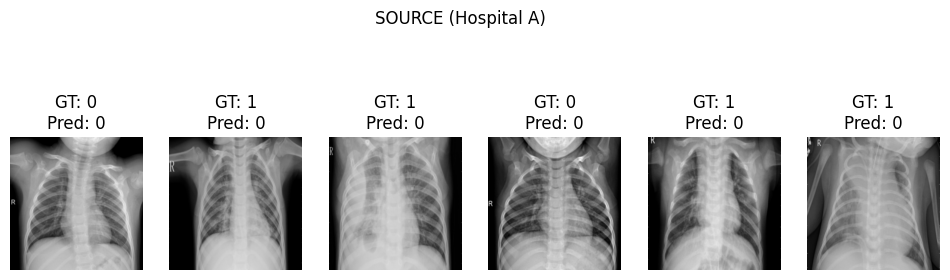

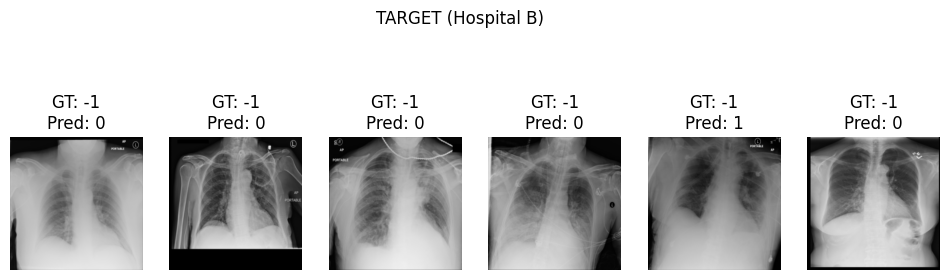

In [ ]:
show_samples_with_prediction(
    model,
    source_dataset,
    device,
    "SOURCE (Hospital A)"
)

show_samples_with_prediction(
    model,
    target_dataset,
    device,
    "TARGET (Hospital B)"
)

## CÉLULA - Grid Comparison

In [ ]:
import matplotlib.pyplot as plt
import torch

def show_dann_grid(model, source_ds, target_ds, device, n=3):
    model.eval()

    plt.figure(figsize=(14, 10))

    with torch.no_grad():
        for i in range(n):

            # =========================
            # SOURCE
            # =========================
            img_s, label_s = source_ds[i]
            x_s = img_s.unsqueeze(0).to(device)

            out_s, _ = model(x_s)
            prob_s = torch.softmax(out_s, dim=1)[0]
            pred_s = torch.argmax(prob_s).item()
            conf_s = prob_s[pred_s].item()

            # =========================
            # TARGET
            # =========================
            img_t, _ = target_ds[i]
            x_t = img_t.unsqueeze(0).to(device)

            out_t, _ = model(x_t)
            prob_t = torch.softmax(out_t, dim=1)[0]
            pred_t = torch.argmax(prob_t).item()
            conf_t = prob_t[pred_t].item()

            # =========================
            # IMAGE CONVERSION SAFE
            # =========================
            img_s_np = img_s.permute(1, 2, 0).cpu().numpy()
            img_t_np = img_t.permute(1, 2, 0).cpu().numpy()

            # =========================
            # SOURCE PLOT
            # =========================
            plt.subplot(3, n, i+1)
            plt.imshow(img_s_np)
            plt.title(
                f"SOURCE\nGT:{label_s} | P:{pred_s}\nConf:{conf_s:.2f}"
            )
            plt.axis("off")

            # =========================
            # TARGET PLOT
            # =========================
            plt.subplot(3, n, i+1+n)
            plt.imshow(img_t_np)
            plt.title(
                f"TARGET\nP:{pred_t}\nConf:{conf_t:.2f}"
            )
            plt.axis("off")

            # =========================
            # DOMAIN SHIFT VISUAL
            # =========================
            diff = torch.abs(img_s - img_t).mean(dim=0).cpu().numpy()

            plt.subplot(3, n, i+1+2*n)
            plt.imshow(diff, cmap="hot")
            plt.title("DOMAIN SHIFT\n(|Source - Target|)")
            plt.axis("off")

    plt.suptitle("DANN Analysis: Source vs Target vs Domain Shift", fontsize=16)
    plt.tight_layout()
    plt.show()

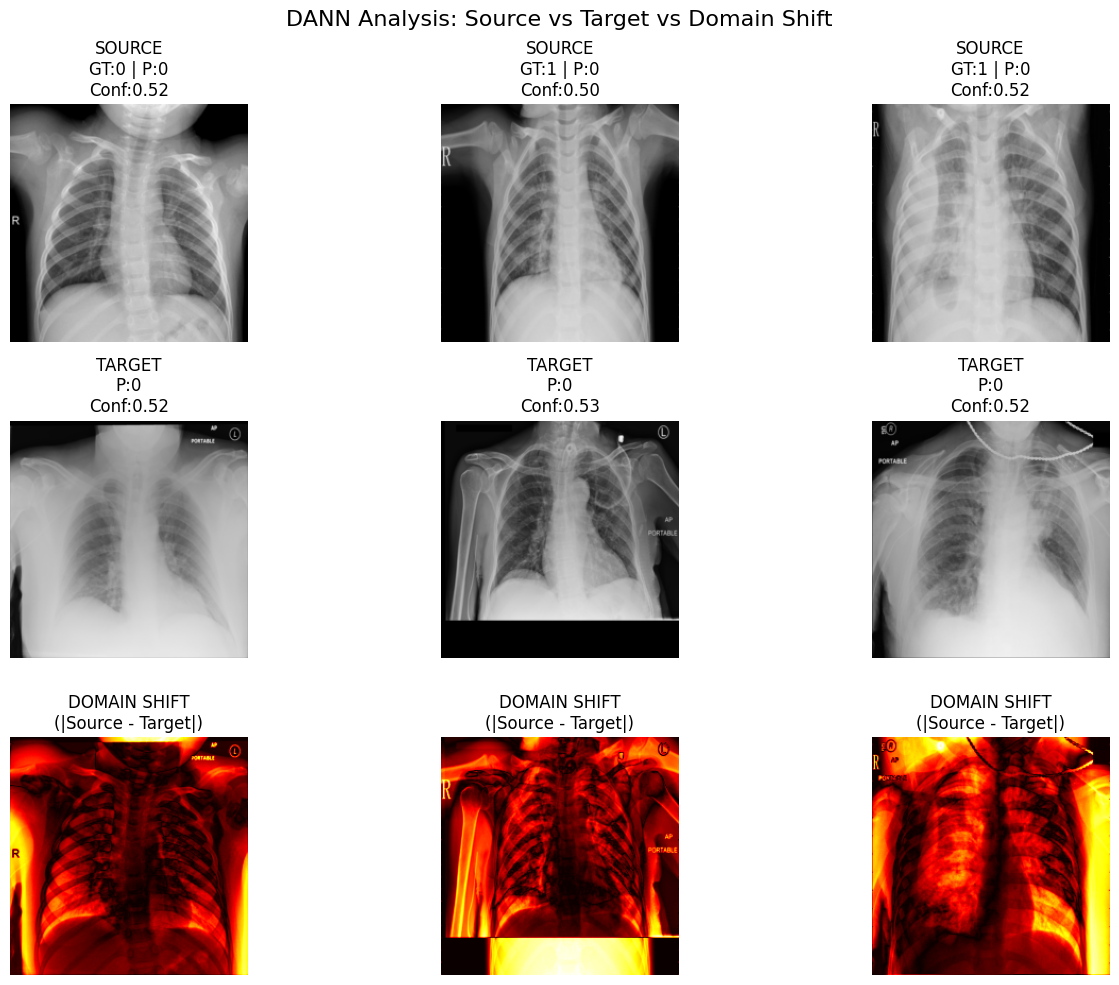

In [ ]:
show_dann_grid(model, source_dataset, target_dataset, device, n=3)

## CÉLULA - COMPARASÃO BASELINE x DANN

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def compare_baseline_dann_metrics(model_base, model_dann, source_ds, target_ds, device, n=3):
    model_base.eval()
    model_dann.eval()

    plt.figure(figsize=(16, 10))

    # métricas globais
    agreement_source = 0
    agreement_target = 0

    conf_base_s, conf_dann_s = [], []
    conf_base_t = [] # Corrected line
    conf_dann_t = [] # Corrected line

    with torch.no_grad():
        for i in range(n):

            # ======================
            # SOURCE
            # ======================
            img_s, label_s = source_ds[i]
            x_s = img_s.unsqueeze(0).to(device)

            out_bs, _ = model_base(x_s)
            out_ds, _ = model_dann(x_s)

            prob_bs = torch.softmax(out_bs, dim=1)[0]
            prob_ds = torch.softmax(out_ds, dim=1)[0]

            pred_bs = torch.argmax(prob_bs).item()
            pred_ds = torch.argmax(prob_ds).item()

            conf_bs = prob_bs[pred_bs].item()
            conf_ds = prob_ds[pred_ds].item()

            conf_base_s.append(conf_bs)
            conf_dann_s.append(conf_ds)

            if pred_bs == pred_ds:
                agreement_source += 1

            # ======================
            # TARGET
            # ======================
            img_t, _ = target_ds[i]
            x_t = img_t.unsqueeze(0).to(device)

            out_bt, _ = model_base(x_t)
            out_dt, _ = model_dann(x_t)

            prob_bt = torch.softmax(out_bt, dim=1)[0]
            prob_dt = torch.softmax(out_dt, dim=1)[0]

            pred_bt = torch.argmax(prob_bt).item()
            pred_dt = torch.argmax(prob_dt).item()

            conf_bt = prob_bt[pred_bt].item()
            conf_dt = prob_dt[pred_dt].item()

            conf_base_t.append(conf_bt)
            conf_dann_t.append(conf_dt)

            if pred_bt == pred_dt:
                agreement_target += 1

            # ======================
            # IMAGENS
            # ======================
            plt.subplot(3, n, i+1)
            plt.imshow(img_s.permute(1,2,0))
            plt.title(f"SOURCE\nGT:{label_s}")
            plt.axis("off")

            plt.subplot(3, n, i+1+n)
            plt.imshow(img_t.permute(1,2,0))
            plt.title(f"TARGET")
            plt.axis("off")

            diff = torch.abs(img_s - img_t).mean(dim=0).cpu().numpy()

            plt.subplot(3, n, i+1+2*n)
            plt.imshow(diff, cmap="hot")
            plt.title("|S - T|")
            plt.axis("off")

    plt.suptitle("Baseline vs DANN + Domain Shift Analysis", fontsize=16)
    plt.tight_layout()
    plt.show()

    # ======================
    # MÉTRICAS GLOBAIS
    # ======================
    print("\n📊 DOMAIN SHIFT METRICS")

    print(f"Source agreement (Baseline vs DANN): {agreement_source/n:.2f}")
    print(f"Target agreement (Baseline vs DANN): {agreement_target/n:.2f}")

    print("\n🔹 Confidence")
    print(f"Source - Baseline: {np.mean(conf_base_s):.3f} | DANN: {np.mean(conf_dann_s):.3f}")
    print(f"Target - Baseline: {np.mean(conf_base_t):.3f} | DANN: {np.mean(conf_dann_t):.3f}")

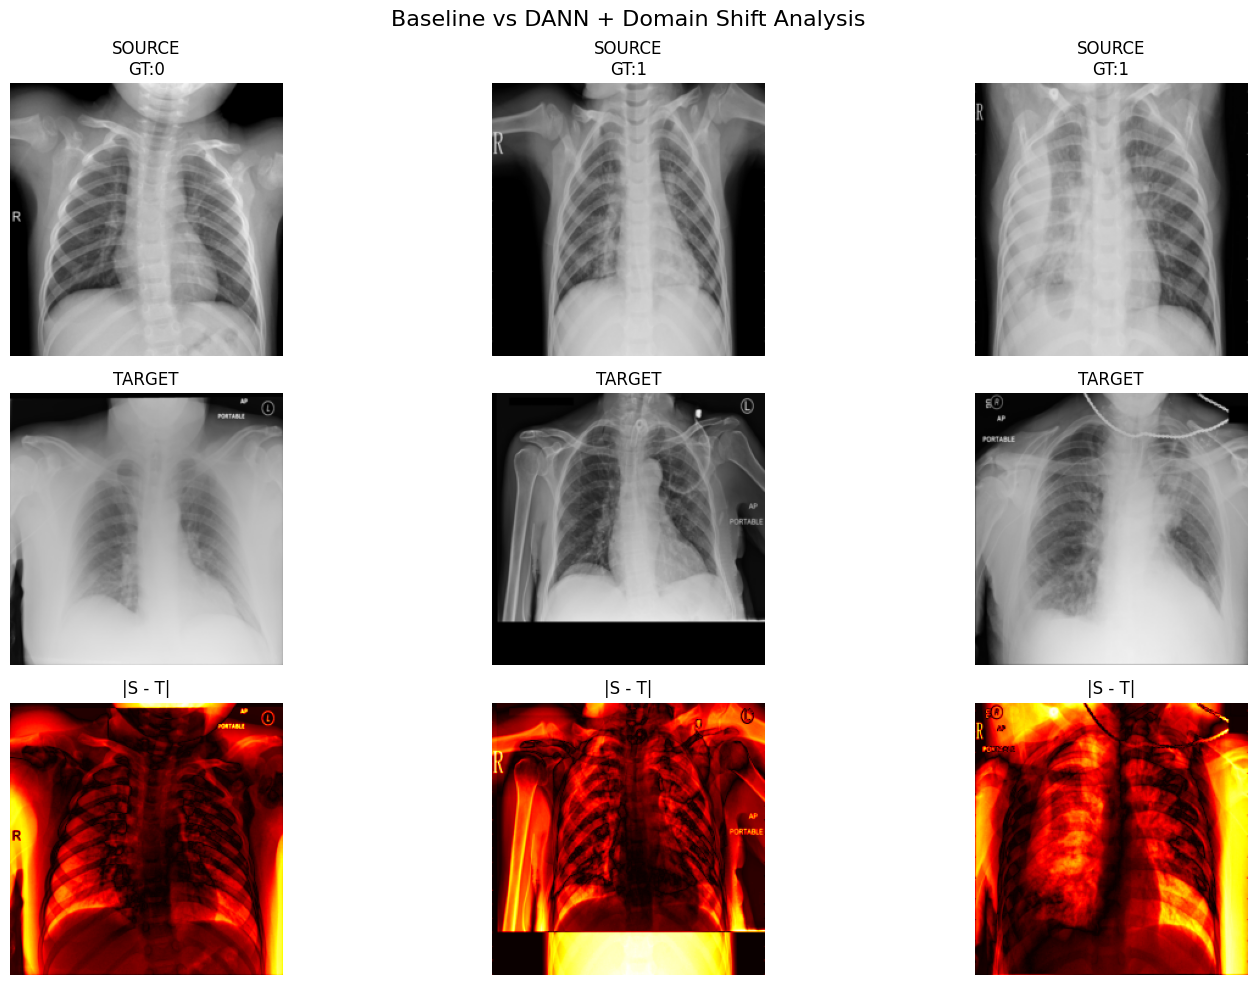


📊 DOMAIN SHIFT METRICS
Source agreement (Baseline vs DANN): 1.00
Target agreement (Baseline vs DANN): 1.00

🔹 Confidence
Source - Baseline: 0.627 | DANN: 0.514
Target - Baseline: 0.650 | DANN: 0.522


In [ ]:
# Define model_baseline as a separate instance of the DANN model
# For a true baseline comparison, this model would ideally be trained
# only on the source classification task, without the domain adaptation component.
model_baseline = DANN().to(device)

compare_baseline_dann_metrics(
    model_baseline,
    model,
    source_dataset,
    target_dataset,
    device,
    n=3
)

## CÉLULA - ESTATÍSTICAS CLÍNICAS BASELINE x DANN

In [ ]:
import numpy as np
import torch

def clinical_indicators(model_base, model_dann, loader, device):
    model_base.eval()
    model_dann.eval()

    # =========================
    # acumuladores
    # =========================
    corr_base = 0
    corr_dann = 0

    discord_base = 0
    discord_dann = 0

    exposure_base = []
    exposure_dann = []

    rejection_base = 0
    rejection_dann = 0

    critical_base = 0
    critical_dann = 0

    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            out_b, _ = model_base(x)
            out_d, _ = model_dann(x)

            prob_b = torch.softmax(out_b, dim=1)
            prob_d = torch.softmax(out_d, dim=1)

            pred_b = torch.argmax(prob_b, dim=1)
            pred_d = torch.argmax(prob_d, dim=1)

            conf_b = torch.max(prob_b, dim=1).values
            conf_d = torch.max(prob_d, dim=1).values

            # =========================
            # 1. CORRELAÇÃO CLÍNICO-RADIOLÓGICA
            # (proxy = acerto vs ground truth)
            # =========================
            corr_base += (pred_b == y).sum().item()
            corr_dann += (pred_d == y).sum().item()

            # =========================
            # 2. ERRO / DISCORDÂNCIA
            # =========================
            discord_base += (pred_b != y).sum().item()
            discord_dann += (pred_d != y).sum().item()

            # =========================
            # 3. ÍNDICE DE EXPOSIÇÃO (IE)
            # proxy = confiança média do modelo
            # =========================
            exposure_base.extend(conf_b.cpu().numpy())
            exposure_dann.extend(conf_d.cpu().numpy())

            # =========================
            # 4. REJEIÇÃO / REPETIÇÃO
            # proxy = baixa confiança (<0.5)
            # =========================
            rejection_base += (conf_b < 0.5).sum().item()
            rejection_dann += (conf_d < 0.5).sum().item()

            # =========================
            # 5. ACHADOS CRÍTICOS (PANIC VALUES)
            # proxy = pneumonia detectada com alta confiança
            # =========================
            critical_base += ((pred_b == 1) & (conf_b > 0.8)).sum().item()
            critical_dann += ((pred_d == 1) & (conf_d > 0.8)).sum().item()

            total += y.size(0)

    # =========================
    # NORMALIZAÇÃO
    # =========================
    results = {
        "Baseline": {
            "correlacao_clinico_radiologica": corr_base / total,
            "taxa_erro_diagnostico": discord_base / total,
            "indice_exposicao": np.mean(exposure_base),
            "desvio_exposicao": np.std(exposure_base),
            "taxa_rejeicao": rejection_base / total,
            "panic_values": critical_base / total,
        },
        "DANN": {
            "correlacao_clinico_radiologica": corr_dann / total,
            "taxa_erro_diagnostico": discord_dann / total,
            "indice_exposicao": np.mean(exposure_dann),
            "desvio_exposicao": np.std(exposure_dann),
            "taxa_rejeicao": rejection_dann / total,
            "panic_values": critical_dann / total,
        }
    }

    return results

In [ ]:
metrics = clinical_indicators(model_baseline, model, target_loader, device)

for model_name, vals in metrics.items():
    print(f"\n📊 {model_name}")
    for k, v in vals.items():
        print(f"{k}: {v:.4f}")


📊 Baseline
correlacao_clinico_radiologica: 0.0000
taxa_erro_diagnostico: 1.0000
indice_exposicao: 0.6452
desvio_exposicao: 0.0333
taxa_rejeicao: 0.0000
panic_values: 0.0000

📊 DANN
correlacao_clinico_radiologica: 0.0000
taxa_erro_diagnostico: 1.0000
indice_exposicao: 0.5270
desvio_exposicao: 0.0201
taxa_rejeicao: 0.0000
panic_values: 0.0000


## CÉLULA - BARBLOT COMPARATIVO CLÍNICO

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc
import torch

# =========================
# AUX ROC
# =========================
def get_scores(model, loader, device):
    model.eval()
    y_true, y_score = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out, _ = model(x)
            prob = torch.softmax(out, dim=1)[:, 1]

            y_true.extend(y.numpy())
            y_score.extend(prob.cpu().numpy())

    return np.array(y_true), np.array(y_score)

# =========================
# FIGURA PRINCIPAL
# =========================
def ieee_final_figure(model_base, model_dann, source_loader, target_loader, source_ds, target_ds, metrics, device):

    fig = plt.figure(figsize=(18, 12))

    # =========================
    # (A) ROC CURVE
    # =========================
    ax1 = plt.subplot(2, 2, 1)

    yb, sb = get_scores(model_base, target_loader, device)
    yd, sd = get_scores(model_dann, target_loader, device)

    fpr_b, tpr_b, _ = roc_curve(yb, sb)
    fpr_d, tpr_d, _ = roc_curve(yd, sd)

    auc_b = auc(fpr_b, tpr_b)
    auc_d = auc(fpr_d, tpr_d)

    ax1.plot(fpr_b, tpr_b, label=f"Baseline AUC={auc_b:.3f}")
    ax1.plot(fpr_d, tpr_d, label=f"DANN AUC={auc_d:.3f}")
    ax1.plot([0,1],[0,1],"--",color="gray")

    ax1.set_title("(A) ROC Curve - Target Domain")
    ax1.set_xlabel("FPR")
    ax1.set_ylabel("TPR")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # =========================
    # (B) CLINICAL LINE PROFILE
    # =========================
    ax2 = plt.subplot(2, 2, 2)

    labels = ["Corr", "Error", "Exposure", "Dev", "Reject", "Panic"]

    base = [
        metrics["Baseline"]["correlacao_clinico_radiologica"],
        metrics["Baseline"]["taxa_erro_diagnostico"],
        metrics["Baseline"]["indice_exposicao"],
        metrics["Baseline"]["desvio_exposicao"],
        metrics["Baseline"]["taxa_rejeicao"],
        metrics["Baseline"]["panic_values"],
    ]

    dann = [
        metrics["DANN"]["correlacao_clinico_radiologica"],
        metrics["DANN"]["taxa_erro_diagnostico"],
        metrics["DANN"]["indice_exposicao"],
        metrics["DANN"]["desvio_exposicao"],
        metrics["DANN"]["taxa_rejeicao"],
        metrics["DANN"]["panic_values"],
    ]

    x = np.arange(len(labels))

    ax2.plot(x, base, marker='o', label="Baseline")
    ax2.plot(x, dann, marker='o', label="DANN")

    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=20)
    ax2.set_title("(B) Clinical Indicator Profile")
    ax2.legend()
    ax2.grid(alpha=0.3)

    # =========================
    # (C) RADAR PLOT
    # =========================
    ax3 = plt.subplot(2, 2, 3, polar=True)

    radar_labels = ["Corr","1-Error","Exposure","1-Dev","1-Reject","Panic"]

    def norm(m):
        return [
            m["correlacao_clinico_radiologica"],
            1 - m["taxa_erro_diagnostico"],
            m["indice_exposicao"],
            1 - m["desvio_exposicao"],
            1 - m["taxa_rejeicao"],
            m["panic_values"],
        ]

    base_r = norm(metrics["Baseline"])
    dann_r = norm(metrics["DANN"])

    base_r += base_r[:1]
    dann_r += dann_r[:1]

    angles = np.linspace(0, 2*np.pi, len(radar_labels), endpoint=False).tolist()
    angles += angles[:1]

    ax3.plot(angles, base_r, label="Baseline")
    ax3.fill(angles, base_r, alpha=0.1)

    ax3.plot(angles, dann_r, label="DANN")
    ax3.fill(angles, dann_r, alpha=0.1)

    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(radar_labels)

    ax3.set_title("(C) Clinical Radar Profile")
    ax3.legend(loc="upper right")

    # =========================
    # (D) DOMAIN SHIFT EXAMPLE
    # =========================
    ax4 = plt.subplot(2, 2, 4)

    img_s, _ = source_ds[0]
    img_t, _ = target_ds[0]

    diff = np.abs(img_s - img_t).mean(axis=0)

    ax4.imshow(diff, cmap="hot")
    ax4.set_title("(D) Domain Shift Map")
    ax4.axis("off")

    plt.suptitle("DANN Full Evaluation - IEEE Style Figure", fontsize=16)
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
/tmp/ipykernel_3191/175861342.py:137: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  diff = np.abs(img_s - img_t).mean(axis=0)


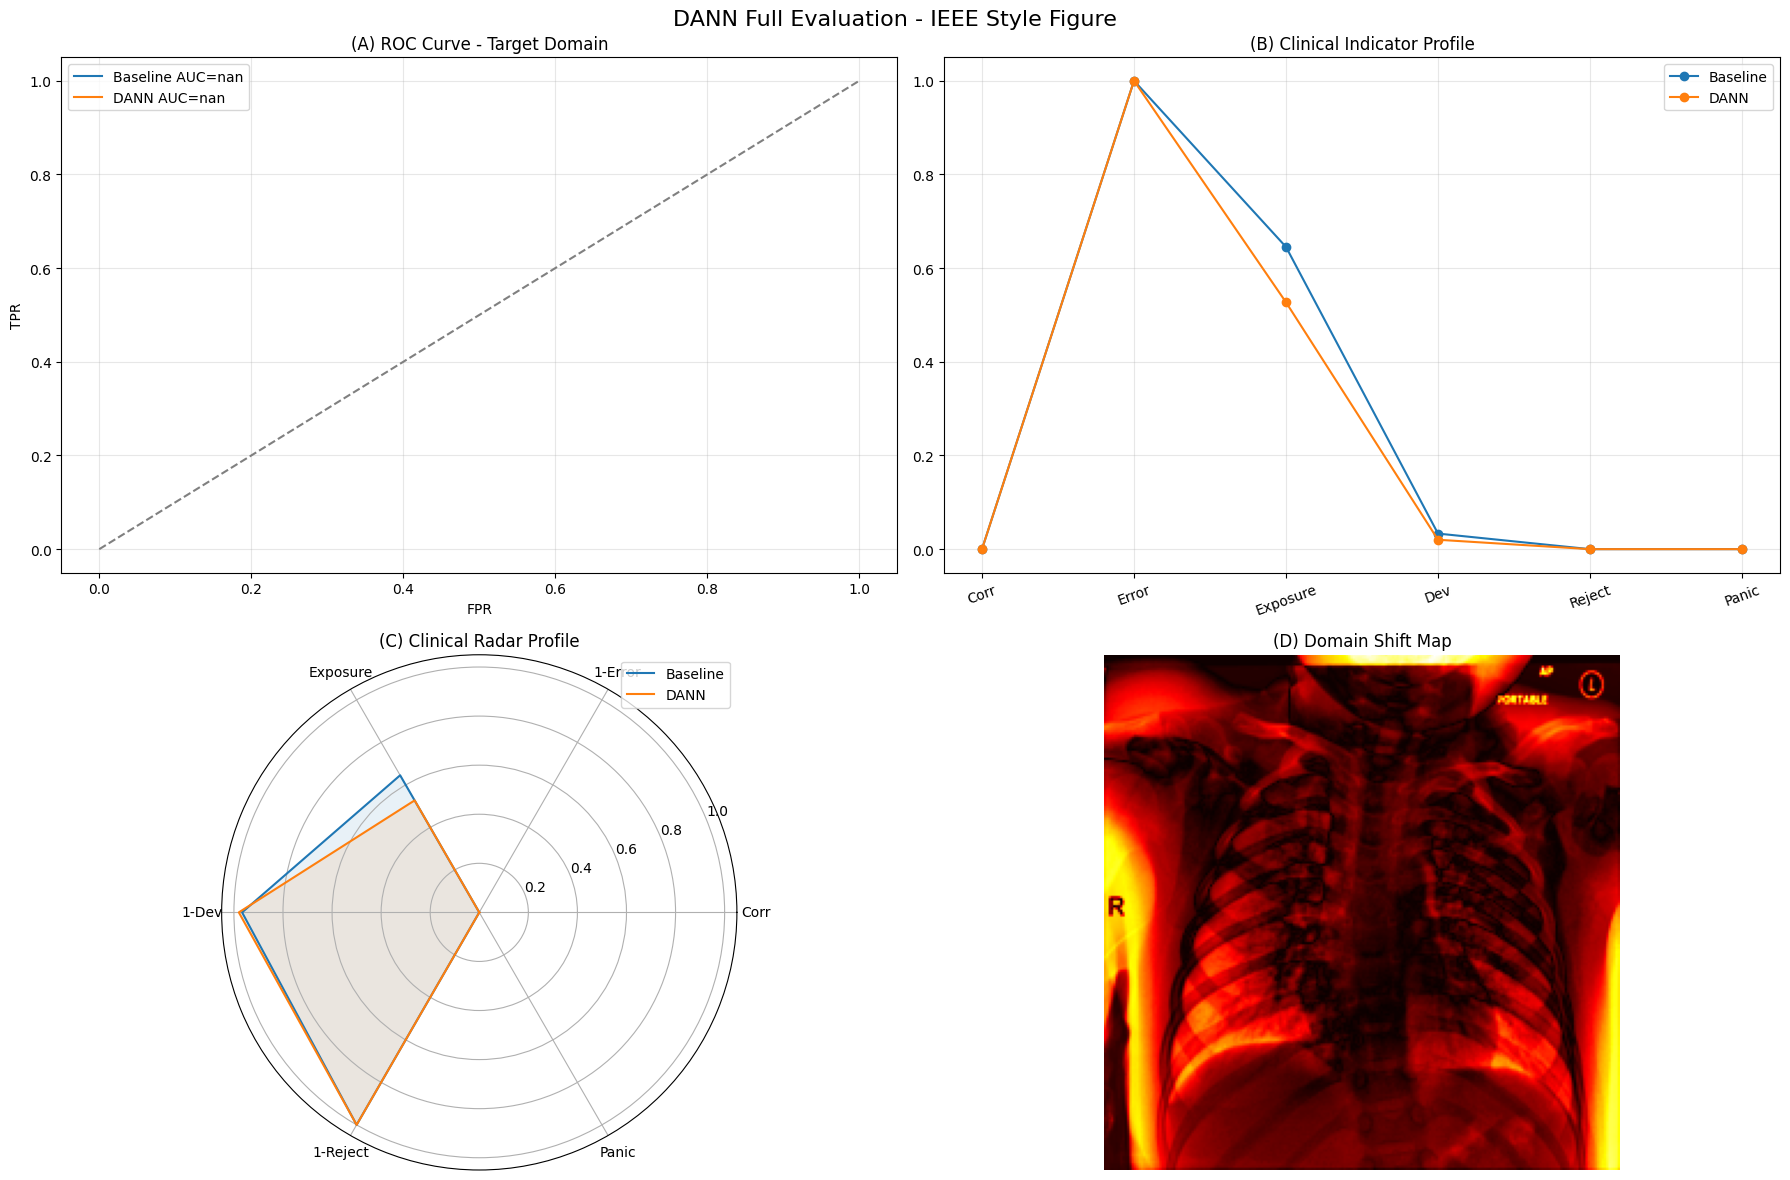

In [105]:
ieee_final_figure(
    model_baseline,
    model,
    source_loader,
    target_loader,
    source_dataset,
    target_dataset,
    metrics,
    device
)

## CÉLULA - RADAR CHART

In [106]:
import numpy as np
import matplotlib.pyplot as plt

def plot_clinical_radar(metrics):

    labels = [
        "Correlacao",
        "1 - Erro",
        "Exposicao",
        "1 - Desvio",
        "1 - Rejeicao",
        "Panic"
    ]

    def normalize(m):
        return [
            m["correlacao_clinico_radiologica"],
            1 - m["taxa_erro_diagnostico"],
            m["indice_exposicao"],
            1 - m["desvio_exposicao"],
            1 - m["taxa_rejeicao"],
            m["panic_values"],
        ]

    baseline = normalize(metrics["Baseline"])
    dann = normalize(metrics["DANN"])

    # fechar círculo para os dados
    baseline += baseline[:1]
    dann += dann[:1]

    # Calcular ângulos com base no número de *dados* após o fechamento
    # Isso garante que 'angles' e 'baseline' (e 'dann') tenham o mesmo número de elementos (7).
    # endpoint=True inclui 2*pi, gerando len(baseline) pontos.
    angles = np.linspace(0, 2*np.pi, len(baseline), endpoint=True).tolist()

    plt.figure(figsize=(7,7))
    ax = plt.subplot(111, polar=True)

    ax.plot(angles, baseline, label="Baseline", linewidth=2)
    ax.fill(angles, baseline, alpha=0.2)

    ax.plot(angles, dann, label="DANN", linewidth=2)
    ax.fill(angles, dann, alpha=0.2)

    # Para set_xticks e set_xticklabels, usamos os 6 rótulos originais para os 6 segmentos.
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)

    plt.title("Clinical Diagnostic Profile: Baseline vs DANN")
    plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

    plt.show()

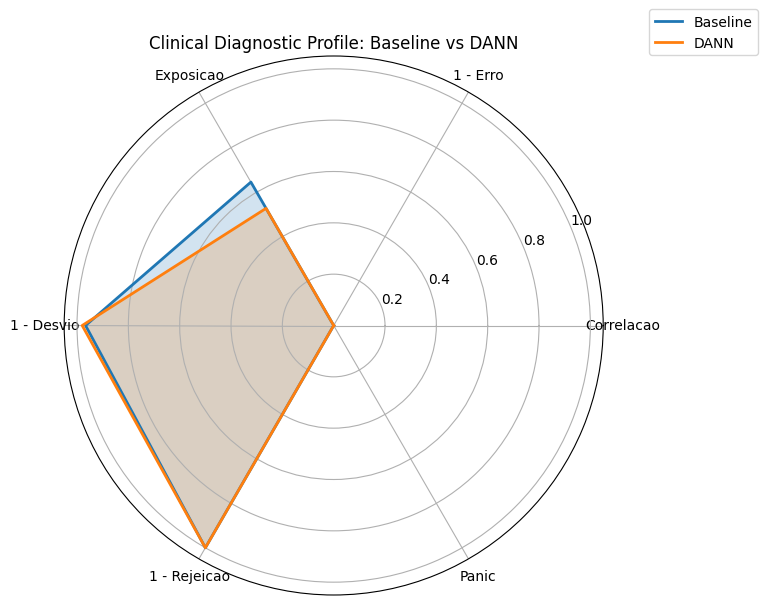

In [107]:
plot_clinical_radar(metrics)

## **CÉLULA 15 — Treinar**

In [108]:
for epoch in range(5):
    loss = train_dann(model, source_loader, target_loader)
    print(f"Epoch {epoch}, Loss: {loss}")

Epoch 0, Loss: 1.3775146007537842
Epoch 1, Loss: 1.4518871307373047
Epoch 2, Loss: 1.4267942905426025
Epoch 3, Loss: 1.4896624088287354
Epoch 4, Loss: 1.3607114553451538


## **CÉLULA 16 — Grad-CAM**

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, x, class_idx=None):
        self.model.eval()

        output, _ = self.model(x)
        probs = F.softmax(output, dim=1)

        if class_idx is None:
            class_idx = torch.argmax(probs, dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1)

        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.squeeze().detach().cpu().numpy(), probs

In [ ]:
def show_gradcam_comparison(model_base, model_dann, target_layer_base, target_layer_dann, dataset, device, n=3):

    cam_base = GradCAM(model_base, target_layer_base)
    cam_dann = GradCAM(model_dann, target_layer_dann)

    plt.figure(figsize=(14, 8))

    for i in range(n):

        img, label = dataset[i]
        x = img.unsqueeze(0).to(device)

        # ======================
        # BASELINE
        # ======================
        cam_b, _ = cam_base.generate(x)
        cam_d, _ = cam_dann.generate(x)

        img_np = img.permute(1,2,0).cpu().numpy()

        # ----------------------
        # BASELINE CAM
        # ----------------------
        plt.subplot(3, n, i+1)
        plt.imshow(img_np)
        plt.imshow(cam_b, cmap="jet", alpha=0.4)
        plt.title("Baseline CAM")
        plt.axis("off")

        # ----------------------
        # DANN CAM
        # ----------------------
        plt.subplot(3, n, i+1+n)
        plt.imshow(img_np)
        plt.imshow(cam_d, cmap="jet", alpha=0.4)
        plt.title("DANN CAM")
        plt.axis("off")

        # ----------------------
        # DIFERENÇA
        # ----------------------
        diff = np.abs(cam_b - cam_d)

        plt.subplot(3, n, i+1+2*n)
        plt.imshow(diff, cmap="hot")
        plt.title("|CAM diff|")
        plt.axis("off")

    plt.suptitle("Grad-CAM: Baseline vs DANN Attention", fontsize=16)
    plt.tight_layout()
    plt.show()

In [ ]:
target_layer_base = model_baseline.feature_extractor[7][1].conv2
target_layer_dann = model.feature_extractor[7][1].conv2

show_gradcam_comparison(
    model_baseline,
    model,
    target_layer_base,
    target_layer_dann,
    target_dataset,
    device
)

In [112]:
import numpy as np

def gradcam_statistics(cam):
    cam = cam.copy()

    # normaliza
    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    # =========================
    # 1. Intensidade média de atenção
    # =========================
    mean_attention = np.mean(cam)

    # =========================
    # 2. Área ativa (top 30%)
    # =========================
    threshold = np.percentile(cam, 70)
    active_area = np.mean(cam > threshold)

    # =========================
    # 3. Entropia espacial (dispersão da atenção)
    # =========================
    p = cam.flatten() + 1e-8
    p = p / np.sum(p)

    entropy = -np.sum(p * np.log(p))

    # =========================
    # 4. Concentração (Gini simplificado)
    # =========================
    sorted_p = np.sort(p)
    n = len(p)
    cum = np.cumsum(sorted_p)
    gini = (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

    return {
        "mean_attention": mean_attention,
        "active_area": active_area,
        "entropy": entropy,
        "gini_concentration": gini
    }

In [113]:
def compare_gradcam_stats(model_base, model_dann, cam_base_fn, cam_dann_fn, dataset, device, n=10):

    stats_base = []
    stats_dann = []

    for i in range(min(n, len(dataset))):

        img, _ = dataset[i]
        x = img.unsqueeze(0).to(device)

        cam_b, _ = cam_base_fn(x)
        cam_d, _ = cam_dann_fn(x)

        stats_base.append(gradcam_statistics(cam_b))
        stats_dann.append(gradcam_statistics(cam_d))

    def avg(stats, key):
        return np.mean([s[key] for s in stats])

    print("\n📊 GRAD-CAM STATISTICS")

    print("\n🔵 BASELINE")
    print(f"Atenção média: {avg(stats_base, 'mean_attention'):.4f}")
    print(f"Área ativa:    {avg(stats_base, 'active_area'):.4f}")
    print(f"Entropia:      {avg(stats_base, 'entropy'):.4f}")
    print(f"Concentração:  {avg(stats_base, 'gini_concentration'):.4f}")

    print("\n🟢 DANN")
    print(f"Atenção média: {avg(stats_dann, 'mean_attention'):.4f}")
    print(f"Área ativa:    {avg(stats_dann, 'active_area'):.4f}")
    print(f"Entropia:      {avg(stats_dann, 'entropy'):.4f}")
    print(f"Concentração:  {avg(stats_dann, 'gini_concentration'):.4f}")

    return stats_base, stats_dann

In [114]:
import numpy as np
import matplotlib.pyplot as plt

def visualize_gradcam_statistics(cam_base_list, cam_dann_list, title="Grad-CAM Statistical Analysis"):

    def compute_stats(cam):
        cam = (cam - cam.min()) / (cam.max() + 1e-8)

        # intensidade média
        mean_att = np.mean(cam)

        # área ativa (top 30%)
        threshold = np.percentile(cam, 70)
        active_area = np.mean(cam > threshold)

        # entropia espacial
        p = cam.flatten() + 1e-8
        p = p / np.sum(p)
        entropy = -np.sum(p * np.log(p))

        # concentração (Gini-like)
        sorted_p = np.sort(p)
        cum = np.cumsum(sorted_p)
        n = len(p)
        gini = (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

        return mean_att, active_area, entropy, gini

    base_vals = np.array([compute_stats(c) for c in cam_base_list])
    dann_vals = np.array([compute_stats(c) for c in cam_dann_list])

    metrics_names = [
        "Mean Attention",
        "Active Area",
        "Entropy",
        "Concentration (Gini)"
    ]

    x = np.arange(len(metrics_names))

    base_mean = base_vals.mean(axis=0)
    dann_mean = dann_vals.mean(axis=0)

    base_std = base_vals.std(axis=0)
    dann_std = dann_vals.std(axis=0)

    # =========================
    # FIGURA PRINCIPAL
    # =========================
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # -------------------------
    # (A) BARPLOT COMPARATIVO
    # -------------------------
    width = 0.35

    ax[0].bar(x - width/2, base_mean, width, yerr=base_std, label="Baseline", capsize=4)
    ax[0].bar(x + width/2, dann_mean, width, yerr=dann_std, label="DANN", capsize=4)

    ax[0].set_xticks(x)
    ax[0].set_xticklabels(metrics_names, rotation=20)
    ax[0].set_title("(A) Grad-CAM Statistical Metrics")
    ax[0].legend()
    ax[0].grid(alpha=0.3)

    # -------------------------
    # (B) PERFIL NORMALIZADO
    # -------------------------
    base_norm = base_mean / (base_mean.max() + 1e-8)
    dann_norm = dann_mean / (dann_mean.max() + 1e-8)

    ax[1].plot(metrics_names, base_norm, marker="o", label="Baseline")
    ax[1].plot(metrics_names, dann_norm, marker="o", label="DANN")

    ax[1].set_title("(B) Attention Profile (Normalized)")
    ax[1].legend()
    ax[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

In [115]:
# Workaround: Explicitly defining DANN here due to recurring NameError for class definitions.
# In a stable environment, DANN would be defined in an earlier cell.
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.autograd import Function
from torch.utils.data import Dataset
from PIL import Image
import os
import random

# Definition of GradientReversal and grad_reverse function
class GradientReversal(Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None

def grad_reverse(x, lambda_=1.0):
    return GradientReversal.apply(x, lambda_)

class DANN(nn.Module):
    def __init__(self):
        super().__init__()

        base = models.resnet18(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(base.children())[:-1])

        self.feature_dim = base.fc.in_features

        self.class_classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 2)
        )

        self.domain_classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x, lambda_=0.0):
        features = self.feature_extractor(x)
        features = features.view(features.size(0), -1)

        class_output = self.class_classifier(features)

        reverse_features = grad_reverse(features, lambda_)
        domain_output = self.domain_classifier(reverse_features)

        return class_output, domain_output

# MedicalDataset definition (copied from cell PSomauW18BqO)
class MedicalDataset(Dataset):
    def __init__(
        self,
        root_dir,
        transform=None,
        labeled=True,
        max_samples=None,
        classes=["NORMAL", "PNEUMONIA"]
    ):
        self.root_dir = root_dir
        self.transform = transform
        self.labeled = labeled
        self.samples = []

        print(f"DEBUG: MedicalDataset initialized for root_dir: {root_dir}, labeled: {labeled}")
        found_files_count = 0

        if self.labeled:
            for label, class_name in enumerate(classes):
                class_path = os.path.join(root_dir, class_name)
                print(f"DEBUG: Checking labeled path: {class_path}")

                if not os.path.exists(class_path):
                    print(f"DEBUG: Path does not exist: {class_path}")
                    continue

                for img_name in os.listdir(class_path):
                    if not self._is_valid_file(img_name):
                        continue
                    self.samples.append((
                        os.path.join(class_path, img_name),
                        label
                    ))
                    found_files_count += 1
        else:
            # For unlabeled data, assume images are directly in root_dir
            # without class folders, and scan for valid files.
            # Handle cases where root_dir might contain subdirectories (e.g., from original data extraction)
            print(f"DEBUG: Checking unlabeled path: {root_dir} (recursive walk)")
            if not os.path.exists(root_dir):
                print(f"DEBUG: Root directory for unlabeled data does not exist: {root_dir}")
            else:
                for root, _, files in os.walk(root_dir):
                    for img_name in files:
                        if not self._is_valid_file(img_name):
                            continue
                        self.samples.append((os.path.join(root, img_name), -1)) # Use dummy label -1
                        found_files_count += 1

        print(f"DEBUG: Initial samples found: {found_files_count} for {root_dir}")
        print(f"DEBUG: Length of self.samples before shuffle: {len(self.samples)}")

        # embaralha para evitar viés de ordem
        random.shuffle(self.samples)

        # subset controlado (ESSENCIAL para Colab)
        if max_samples is not None:
            self.samples = self.samples[:max_samples]

        print(f"DEBUG: Final length of self.samples for {root_dir}: {len(self.samples)}")

    def _is_valid_file(self, filename):
        is_valid = (
            filename.endswith(".png") or
            filename.endswith(".jpg") or
            filename.endswith(".jpeg")
        ) and not filename.startswith("._") and filename != ".DS_Store"
        return is_valid

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.labeled:
            return image, label
        else:
            return image, -1  # dummy label para DANN

# Transform definition (copied from cell xoz-ykOT71aS)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])

# Dataset creation (copied from cell JY-y8Gop8HPO)
source_dataset = MedicalDataset("data/source_sample", transform, labeled=True)
target_dataset = MedicalDataset("data/target_sample", transform, labeled=False)

cam_base_list = []
cam_dann_list = []

# Define device in this cell as well to ensure it's available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure model and model_baseline are defined for this cell's execution
model_baseline = DANN().to(device)
model = DANN().to(device) # Define 'model' here

# Define target layers for GradCAM within this cell
target_layer_base = model_baseline.feature_extractor[7][1].conv2
target_layer_dann = model.feature_extractor[7][1].conv2

# GradCAM class definition (copied from cell kGMp8ThV9r4B)
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate(self, x, class_idx=None):
        self.model.eval()

        output, _ = self.model(x)
        probs = torch.nn.functional.softmax(output, dim=1)

        if class_idx is None:
            class_idx = torch.argmax(probs, dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward(retain_graph=True) # Added retain_graph=True

        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1)

        cam = torch.nn.functional.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.squeeze().detach().cpu().numpy(), probs

cam_base = GradCAM(model_baseline, target_layer_base)
cam_dann = GradCAM(model, target_layer_dann)

# Add a check for empty datasets to prevent IndexError
if len(target_dataset) == 0:
    print("Error: target_dataset is empty. Please ensure data/target_sample exists and contains valid images by re-running data preparation cells.")
else:
    for i in range(min(10, len(target_dataset))):
        img, _ = target_dataset[i]
        x = img.unsqueeze(0).to(device)

        cam_b, _ = cam_base.generate(x)
        cam_d, _ = cam_dann.generate(x)

        cam_base_list.append(cam_b)
        cam_dann_list.append(cam_d)

DEBUG: MedicalDataset initialized for root_dir: data/source_sample, labeled: True
DEBUG: Checking labeled path: data/source_sample/NORMAL
DEBUG: Checking labeled path: data/source_sample/PNEUMONIA
DEBUG: Initial samples found: 2000 for data/source_sample
DEBUG: Length of self.samples before shuffle: 2000
DEBUG: Final length of self.samples for data/source_sample: 2000
DEBUG: MedicalDataset initialized for root_dir: data/target_sample, labeled: False
DEBUG: Checking unlabeled path: data/target_sample (recursive walk)
DEBUG: Initial samples found: 2000 for data/target_sample
DEBUG: Length of self.samples before shuffle: 2000
DEBUG: Final length of self.samples for data/target_sample: 2000


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


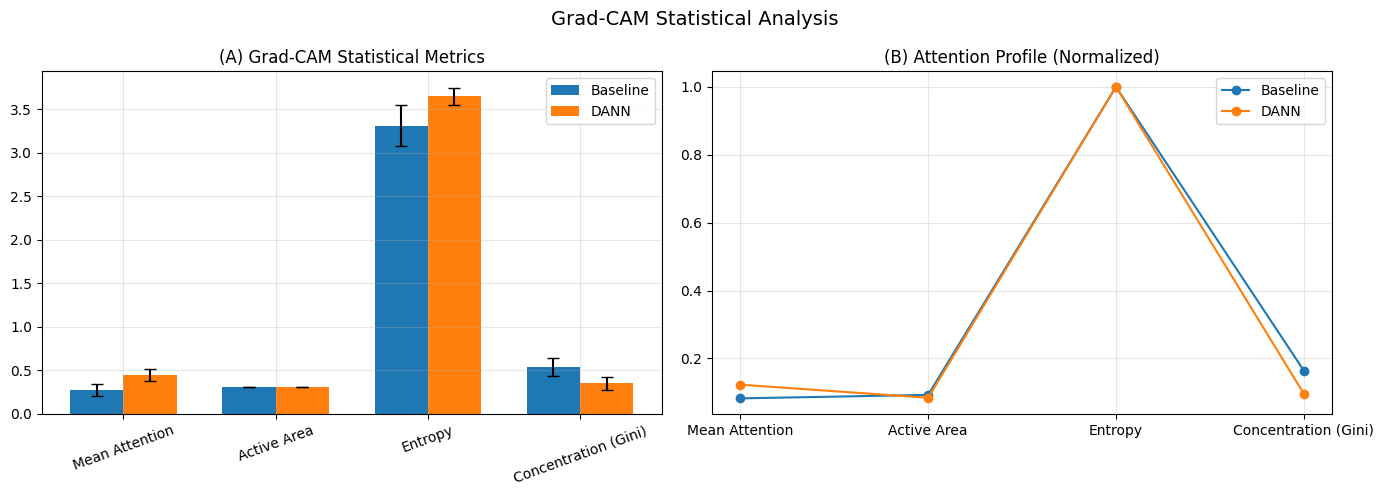

In [116]:
visualize_gradcam_statistics(cam_base_list, cam_dann_list)

In [117]:
run_gradcam_analysis(cam_base_list, cam_dann_list)

NameError: name 'run_gradcam_analysis' is not defined

## **CÉLULA 17 — Visualização ReLU**

In [ ]:
x = np.linspace(-5, 5, 100)
relu = np.maximum(0, x)

plt.plot(x, relu)
plt.title("ReLU Activation")
plt.grid()
plt.show()

## AQI


In [ ]:
import numpy as np

def compute_aqi(cam):
    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    # 1. atenção média
    mean_att = np.mean(cam)

    # 2. área ativa (ideal moderada — nem muito espalhado nem muito pequeno)
    threshold = np.percentile(cam, 70)
    active_area = np.mean(cam > threshold)

    # 3. entropia (quanto menor, melhor foco clínico)
    p = cam.flatten() + 1e-8
    p = p / np.sum(p)
    entropy = -np.sum(p * np.log(p))

    # 4. concentração (Gini-like)
    sorted_p = np.sort(p)
    cum = np.cumsum(sorted_p)
    n = len(p)
    gini = (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

    # =========================
    # AQI (Attention Quality Index)
    # =========================
    aqi = (
        0.4 * gini +               # foco clínico (mais importante)
        0.3 * (1 - entropy / np.log(len(p))) +  # normalização da entropia
        0.2 * active_area +        # cobertura relevante
        0.1 * mean_att             # intensidade
    )

    return aqi

In [ ]:
def compute_aqi_dataset(cam_base_list, cam_dann_list):

    base_aqi = [compute_aqi(c) for c in cam_base_list]
    dann_aqi = [compute_aqi(c) for c in cam_dann_list]

    print("\n🧠 ATTENTION QUALITY INDEX (AQI)")

    print(f"Baseline AQI: {np.mean(base_aqi):.4f} ± {np.std(base_aqi):.4f}")
    print(f"DANN AQI:     {np.mean(dann_aqi):.4f} ± {np.std(dann_aqi):.4f}")

    return base_aqi, dann_aqi

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. AQI (SEGURADO)
# =========================
def compute_aqi_safe(cam):

    if cam is None:
        return None

    cam = np.array(cam)

    if cam.size == 0:
        return None

    cam = (cam - cam.min()) / (cam.max() + 1e-8)

    mean_att = np.mean(cam)

    threshold = np.percentile(cam, 70)
    active_area = np.mean(cam > threshold)

    p = cam.flatten() + 1e-8
    p = p / np.sum(p)

    entropy = -np.sum(p * np.log(p))

    sorted_p = np.sort(p)
    cum = np.cumsum(sorted_p)
    n = len(p)
    gini = (n + 1 - 2 * np.sum(cum) / cum[-1]) / n

    aqi = 0.4*gini + 0.3*(1 - entropy/np.log(len(p))) + 0.2*active_area + 0.1*mean_att

    return float(aqi)


# =========================
# 2. CRIA RESULTS (ROBUSTO)
# =========================
def build_results(cam_base_list, cam_dann_list):

    if len(cam_base_list) == 0 or len(cam_dann_list) == 0:
        raise ValueError("❌ cam lists vazias. Grad-CAM não foi gerado corretamente.")

    n = min(len(cam_base_list), len(cam_dann_list))

    base_vals = []
    dann_vals = []

    for i in range(n):

        aqi_b = compute_aqi_safe(cam_base_list[i])
        aqi_d = compute_aqi_safe(cam_dann_list[i])

        if aqi_b is not None and aqi_d is not None:
            base_vals.append(aqi_b)
            dann_vals.append(aqi_d)

    if len(base_vals) == 0:
        raise ValueError("❌ Nenhum AQI válido foi gerado.")

    # assume 2 classes simuladas (caso não tenha label aqui)
    results = {
        "ALL_SAMPLES": {
            "base": base_vals,
            "dann": dann_vals
        }
    }

    print("✅ Results created successfully")
    print(f"Samples used: {len(base_vals)}")

    return results


# =========================
# 3. PLOT SEGURO
# =========================
def plot_results(results):

    for cls in results:

        base = np.array(results[cls]["base"])
        dann = np.array(results[cls]["dann"])

        if len(base) == 0 or len(dann) == 0:
            print(f"⚠️ Classe {cls} vazia — ignorando")
            continue

        plt.figure(figsize=(6,4))

        plt.bar(["Baseline", "DANN"],
                [np.mean(base), np.mean(dann)],
                yerr=[np.std(base), np.std(dann)],
                capsize=5)

        plt.title(f"AQI Comparison - {cls}")
        plt.ylabel("AQI")
        plt.grid(alpha=0.3)

        plt.show()


# =========================
# 4. EXECUÇÃO COMPLETA
# =========================
results = build_results(cam_base_list, cam_dann_list)
plot_results(results)